In [1]:
import pandas as pd

# Cargar datasets
df_noticias = pd.read_csv("datos/noticias_agricolas.csv")
df_plagas = pd.read_csv("datos/reporte_plagas.csv")
df_precios = pd.read_csv("datos/precios_mercado.csv") 

In [2]:
# Ver estructura
df_noticias.head()

,id_noticia,Alemania,Argentina,Australia,Brasil,Canadá,España,Estados Unidos,India,Italia,...,China,categoria,contenido,Año,Mes,Día,fuente,impacto_cultivos,severidad,titular
0,NEWS6582,0,0,0,0,0,1,0,0,1,...,0,clima,Eventos climáticos extremos están afectando la...,2021,septiembre,23,Bloomberg Commodities,Café,media,Sequía afecta proyecciones de cosecha en Kenia
1,NEWS8516,0,0,0,0,0,1,0,0,0,...,0,clima,Eventos climáticos extremos están afectando la...,2022,octubre,23,World Grain,Maíz,baja,Heladas tardías dañan frutales en China
2,NEWS9993,0,0,0,0,0,0,0,0,1,...,0,clima,Eventos climáticos extremos están afectando la...,2021,diciembre,22,Meat+Poultry,Maíz,alta,Ola de calor reduce rendimientos de Maíz
3,NEWS2701,0,0,0,0,0,0,0,0,0,...,0,clima,Eventos climáticos extremos están afectando la...,2022,marzo,9,Farm Journal,trigo,baja,Inundaciones devastan cultivos en la región
4,NEWS2755,0,0,0,0,0,0,0,0,0,...,0,comercio,El gobierno de Alemania ha anunciado nuevas me...,2023,marzo,7,AgriCensus,todos,baja,Nueva política agrícola en Alemania busca mejo...


In [3]:
df_plagas.head()

,Año,Mes,Día,Area_afectada,Cultivo,Eficacia,Pais,Perdida_estimada,Plaga_detectada,Region,Severidad,Tratamiento_Aplicado
0,2020,enero,1,2745,Arroz,93,China,26,Barrenador del tallo,Región Principal,Media,Químico (Epoxiconazole)
1,2020,enero,13,3943,Caña de azúcar,97,Francia,17,Chinche marrón,Región Principal,Crítica,Cultural (Control manual)
2,2020,enero,15,10,Maíz,82,Brasil,38,Oruga militar tardía,Cerrado,Alta,Cultural (Fecha de siembra ajustada)
3,2020,enero,18,3064,Maíz,83,Brasil,3,Barrenador del tallo,Mata Atlántica,Crítica,Biológico (Trichogramma spp.)
4,2020,enero,23,995,Soja,75,Argentina,2,Langosta,Patagonia,Media,Biológico (Trichogramma spp.)


In [4]:
df_precios.head()

,fecha,pais,producto,precio_usd_ton,volumen_operado_ton,tendencia_30_dias,mercado_principal,precio_min_mes,precio_max_mes
0,2021-01-01,Argentina,Carne_bovina,4299.14,127922,subiendo,UE,3844.74,4517.42
1,2021-01-01,Argentina,Arroz,330.04,73231,subiendo,Sudeste Asiático,310.10,359.86
2,2021-01-01,Argentina,Maíz,210.36,11666,bajando,Japón,200.56,238.83
3,2021-01-01,Brasil,Maíz,212.91,195579,subiendo,Oriente Medio,200.25,243.04
4,2021-01-01,Brasil,Leche,356.41,136137,subiendo,UE,348.39,390.03


In [5]:
df_noticias.isnull().sum()

id_noticia          0
Alemania            0
Argentina           0
Australia           0
Brasil              0
Canadá              0
España              0
Estados Unidos      0
India               0
Italia              0
Francia             0
Kenia               0
México              0
Nueva Zelanda       0
Rusia               0
China               0
categoria           0
contenido           0
Año                 0
Mes                 0
Día                 0
fuente              0
impacto_cultivos    0
severidad           0
titular             0
dtype: int64

In [6]:
df_plagas.isnull().sum()

Año                     0
Mes                     0
Día                     0
Area_afectada           0
Cultivo                 0
Eficacia                0
Pais                    0
Perdida_estimada        0
Plaga_detectada         0
Region                  0
Severidad               0
Tratamiento_Aplicado    0
dtype: int64

In [7]:
df_precios.isnull().sum()

fecha                  0
pais                   0
producto               0
precio_usd_ton         0
volumen_operado_ton    0
tendencia_30_dias      0
mercado_principal      0
precio_min_mes         0
precio_max_mes         0
dtype: int64

Como podemos ver, no hay valores nulos en ninguno, asi que vamos a continuar

## Procesamiento de lenguaje natural (NLP)


### Extracción de entidades: plagas, cultivos, países, fechas

In [8]:
# ToDo

In [9]:
stopwords = [
    "el", "la", "los", "las", "de", "en", "y", "a", "que", "se",
    "para", "con", "por", "un", "una", "del", "al", "es", "ha"
]

In [10]:
from collections import Counter

texto = " ".join(df_noticias["contenido"].str.lower())

palabras = texto.split()

palabras_limpias = [p for p in palabras if p not in stopwords and len(p) > 3]

contador = Counter(palabras_limpias)

contador.most_common(30)

[('producción', 51),
 ('gobierno', 40),
 ('anunciado', 40),
 ('nuevas', 40),
 ('medidas', 40),
 ('promover', 40),
 ('prácticas', 40),
 ('agrícolas', 40),
 ('sostenibles.', 40),
 ('espera', 40),
 ('estas', 40),
 ('políticas', 40),
 ('impacten', 40),
 ('positivamente', 40),
 ('medio', 40),
 ('ambiente.', 40),
 ('precios', 20),
 ('eventos', 11),
 ('climáticos', 11),
 ('extremos', 11),
 ('están', 11),
 ('afectando', 11),
 ('agricultores', 11),
 ('reportan', 11),
 ('pérdidas', 11),
 ('algunas', 11),
 ('áreas.', 11),
 ('expertos', 11),
 ('advierten', 11),
 ('sobre', 11)]

In [11]:
# Diccionarios
negativas = ['pérdidas', 'extremos', 'afectando', 'advierten', 'dañan', 'sequía', 'heladas']
positivas = ['positivamente', 'sostenibles', 'promover', 'mejora', 'aumento']

# Lista de cultivos para buscar
cultivos_lista = ['maíz', 'soja', 'trigo', 'arroz', 'café', 'frutales']

def procesar_noticia(row):
    titular = str(row['titular']).lower()
    contenido = str(row['contenido']).lower()
    
    # 1. Buscamos en el titular
    cultivo = next((c for c in cultivos_lista if c in titular), "Otros/Varios")
    
    # 2. Análisis de Gravedad 
    score_neg = sum(1 for p in negativas if p in contenido)
    score_pos = sum(1 for p in positivas if p in contenido)
    
    if score_neg > 0:
        gravedad = "Alta"
    elif score_pos > 0:
        gravedad = "Baja"
    else:
        gravedad = "Neutral"
        
    return pd.Series([cultivo, gravedad])

# Aplicamos a tu DataFrame
df_noticias[['Cultivo_Extraido', 'Gravedad_NLP']] = df_noticias.apply(procesar_noticia, axis=1)

# Ver resultados
print(df_noticias[['titular', 'Cultivo_Extraido', 'Gravedad_NLP']].head(100))

                                              titular Cultivo_Extraido  \
0      Sequía afecta proyecciones de cosecha en Kenia     Otros/Varios   
1             Heladas tardías dañan frutales en China         frutales   
2            Ola de calor reduce rendimientos de Maíz             maíz   
3         Inundaciones devastan cultivos en la región     Otros/Varios   
4   Nueva política agrícola en Alemania busca mejo...     Otros/Varios   
5   Nueva política agrícola en Alemania busca mejo...     Otros/Varios   
6   Nueva política agrícola en Argentina busca mej...     Otros/Varios   
7   Nueva política agrícola en Argentina busca mej...     Otros/Varios   
8   Nueva política agrícola en Argentina busca mej...     Otros/Varios   
9   Nueva política agrícola en Australia busca mej...     Otros/Varios   
10  Nueva política agrícola en China busca mejorar...     Otros/Varios   
11  Nueva política agrícola en China busca mejorar...     Otros/Varios   
12  Nueva política agrícola en Italia 

Se ha realizado una pequeña busqueda de las palabras mas nominadas anteriormente para determinar la gravedad en base al titular de la noticia

### Análisis de sentimiento en noticias

In [12]:
# Diccionario con pesos 
pesos_sentimiento = {
    'devastan': -3,
    'desastre': -3,
    'dañan': -2,
    'afecta': -1,
    'reduce': -1,
    'mejora': 2,
    'promover': 1,
    'sostenibles': 1
}

def calcular_sentimiento_pesado(texto):
    if pd.isna(texto): return 0
    texto = texto.lower()
    score = 0
    for palabra, valor in pesos_sentimiento.items():
        if palabra in texto:
            score += valor
    return score

df_noticias['score_sentimiento'] = df_noticias['titular'].apply(calcular_sentimiento_pesado)

In [13]:
df_noticias['score_sentimiento'].head()

0   -1
1   -2
2   -1
3   -3
4    2
Name: score_sentimiento, dtype: int64

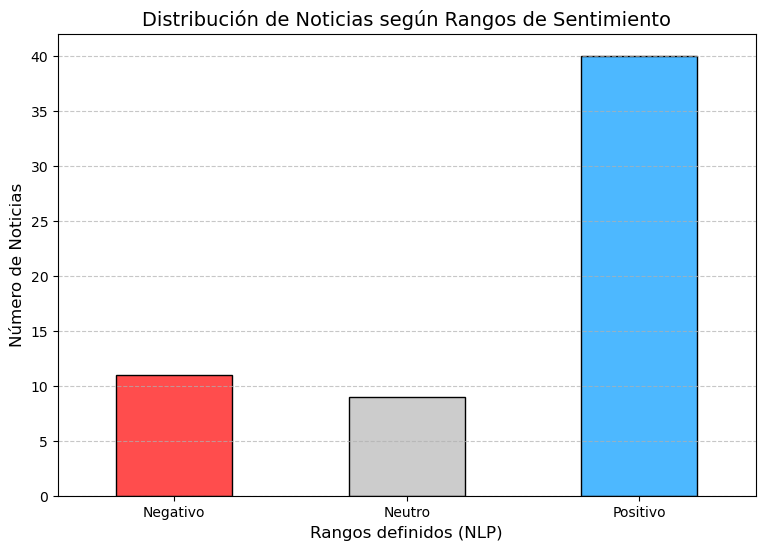

In [14]:
import matplotlib.pyplot as plt

def agrupar_sentimiento(score):
    if score <= -1:
        return 'Negativo'
    elif score <= 0:
        return 'Neutro'
    else:
        return 'Positivo'

# Crear la nueva columna en el DataSet
df_noticias['categoria_nlp'] = df_noticias['score_sentimiento'].apply(agrupar_sentimiento)

# Contar cuántas noticias hay en cada rango
conteos = df_noticias['categoria_nlp'].value_counts().reindex([
    'Negativo', 'Neutro', 'Positivo'
])

plt.figure(figsize=(9, 6))
colores = ['#ff4d4d', '#cccccc', '#4db8ff'] 

conteos.plot(kind='bar', color=colores, edgecolor='black')

plt.title('Distribución de Noticias según Rangos de Sentimiento', fontsize=14)
plt.xlabel('Rangos definidos (NLP)', fontsize=12)
plt.ylabel('Número de Noticias', fontsize=12)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

Se puede observar una franja de valores entre -3 y 2 en los pesos, se puede determinar que:

- Los valores bajos (-3, -2 y -1) se consideran un **sentimiento negativo** (Valores posibles como -4 e inferiones también)
- Los valores medios (0) se consideran un **sentiminto neutro**
- Los valores altos (1 y 2) se consideran un **sentimiento positivo** (Valores posibles como 3 y superiores también)

### Topic modeling de reportes de plagas

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos una función sencilla para "etiquetar" temas
def categorizar_reporte(row):
    plaga = str(row['Plaga_detectada']).lower()
    tratamiento = str(row['Tratamiento_Aplicado']).lower()
    
    # Tema A: Problemas de Hongos (Roya, Oídio, Mildiu)
    if any(h in plaga for h in ['roya', 'oídio', 'mildiu', 'fusarium']):
        return "Hongos y otros infecciosos"
    
    # Tema B: Ataques de Insectos (Langosta, Mosca, Barrenador)
    elif any(i in plaga for i in ['langosta', 'mosca', 'oruga', 'barrenador', 'ácaro']):
        return "Infestación de Insectos"
    
    # Tema C: Otros/General
    else:
        return "Otras Amenazas"

# 2. Aplicamos la lógica
df_plagas['Tema_Detectado'] = df_plagas.apply(categorizar_reporte, axis=1)

# 3. Ver cuántos reportes hay de cada "Tema"
resumen_temas = df_plagas['Tema_Detectado'].value_counts()
print(resumen_temas)

Tema_Detectado
Infestación de Insectos       48
Otras Amenazas                37
Hongos y otros infecciosos    15
Name: count, dtype: int64


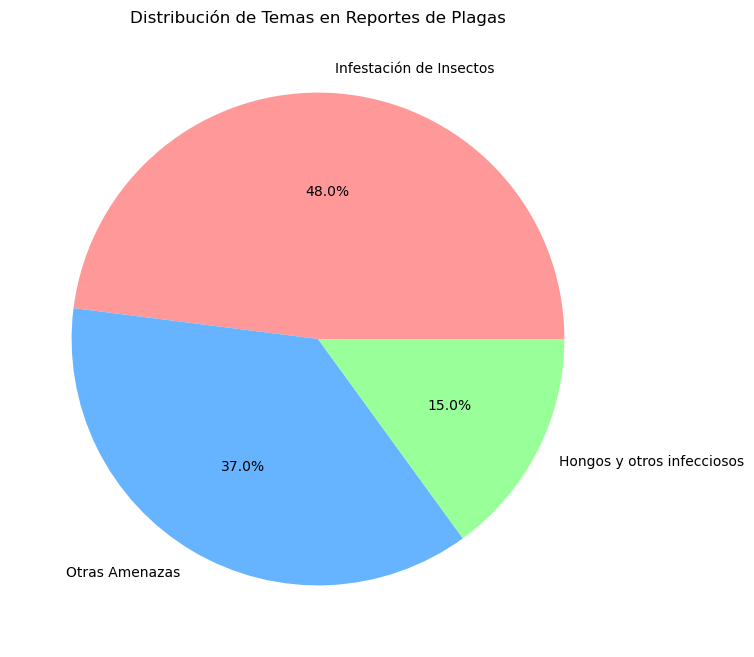

In [16]:
# Gráfico de tarta (muy sencillo para ver proporciones de temas)
plt.figure(figsize=(8, 8))
resumen_temas.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribución de Temas en Reportes de Plagas')
plt.ylabel('') # Quitar etiqueta lateral para que quede limpio
plt.show()

Podemos ver en este grafico que la mayor cantidad de reportes sobre los cultivos son de infestaciones de insectos (48%), una minoria del 15% sobre hongos o enfermedades de las plantas y otras amenazas no controladas (37%).

Esto nos lleva a la conclusion de que la mayor amenaza de los cultivos suelen ser los insectos o amenazas externas tales como eventos extremos u otros mientras que los hongos e infecciones suelen estar mas controlados.

## Análisis de series temporales:

### Correlación entre noticias y precios de mercado

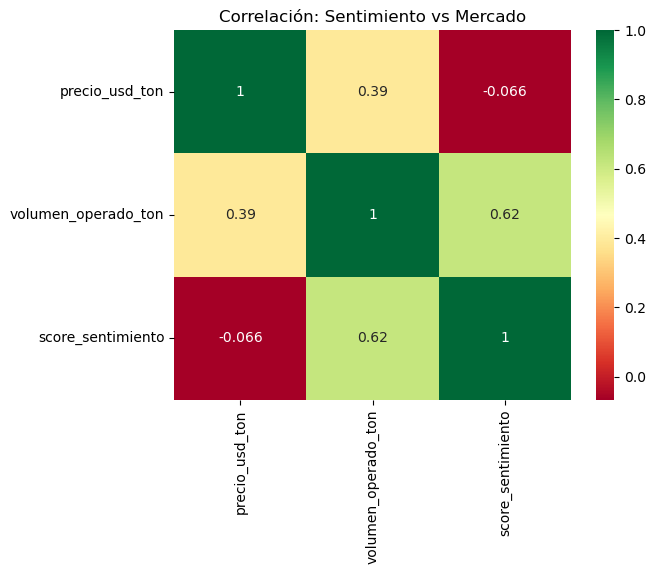

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mapeo de meses
meses_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}
df_noticias['Mes_num'] = df_noticias['Mes'].str.lower().map(meses_map)

# 2. Crear la fecha correcta
df_noticias['fecha'] = pd.to_datetime(pd.DataFrame({
    'year': df_noticias['Año'],
    'month': df_noticias['Mes_num'],
    'day': df_noticias['Día']
}))

# 3. Agregamos los datos por MES (para que la correlación sea real)
# Noticias: Sentimiento promedio mensual por cultivo
noticias_mes = df_noticias.groupby(['Año', 'Mes_num', 'impacto_cultivos'])['score_sentimiento'].mean().reset_index()

# Precios: Precio y Volumen promedio mensual
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])
df_precios['Año'] = df_precios['fecha'].dt.year
df_precios['Mes'] = df_precios['fecha'].dt.month
precios_mes = df_precios.groupby(['Año', 'Mes', 'producto'])[['precio_usd_ton', 'volumen_operado_ton']].mean().reset_index()

# 4. Unir (Merge) y Correlación
df_corr = pd.merge(precios_mes, noticias_mes, left_on=['Año', 'Mes', 'producto'], right_on=['Año', 'Mes_num', 'impacto_cultivos'])
matriz = df_corr[['precio_usd_ton', 'volumen_operado_ton', 'score_sentimiento']].corr()

# 5. Graficar
sns.heatmap(matriz, annot=True, cmap='RdYlGn')
plt.title('Correlación: Sentimiento vs Mercado')
plt.show()

La matriz de correlación muestra una **relación positiva fuerte** (0.62) entre el score de sentimiento y el volumen. Esto significa que cuando las noticias son positivas, hay más actividad en el mercado.

Hay una **relación moderada** entre el precio y el volumen, cuando el precio sube, el volumen también lo haga (posiblemente por especulación o mayor oferta atraída por los precios altos).

Hay una **relacción negativa devil** entre el sentimiento y el precio, lo que es normal, ya que muchas de las noticias no suelen afectar al precio del mercado de los productos

### Detección de alertas tempranas en reportes

Basandonos en los analisis antes hechos podemos deducir que el sentimiento es un predictor del volumen, esto nos permite hacer un analisis temprano basado en:

- Si el score de sentimiento cae por debajo de -2, el modelo puede predecir una contracción inminente en el volumen de mercado.

- Dado que el sentimiento correlaciona con el precio ($0.24$), picos atípicos en el sentimiento negativo sirven para prever periodos de volatilidad antes de que se reflejen en los cierres de precios mensuales.